<a href="https://colab.research.google.com/github/divyadharshiniug/24ADI006_24BAD023/blob/EX-3/DL_EXP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPT NO: 3 — Implementation of Convolutional Neural Networks (CNNs) for Image Classification

**Name:** DIVYADHARSHINI U G
**Roll No:** 24BAD023


## Task A: DATASET PREPARATION
- Download/Load an image dataset (CIFAR-10).
- Preprocess images by resizing and normalization.
- Split the dataset into training, validation, and testing sets.


In [ ]:
# ============================================================
# Install / Import required libraries
# ============================================================
# TensorFlow/Keras is used to build and train the CNN.
# NumPy is used for numerical operations on arrays.
# Matplotlib is used to visualize images and training curves.
# Scikit-learn is used for the confusion matrix and classification report.

#24BAD023
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow version:", tf.__version__)

# Set random seeds for reproducibility of results
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# Task A.1: Load the CIFAR-10 dataset
# ============================================================
# CIFAR-10 is a benchmark dataset consisting of 60,000 32x32 color images
# in 10 classes (6,000 images per class): airplane, automobile, bird, cat,
# deer, dog, frog, horse, ship, truck.
# It is bundled directly with Keras, so no manual Kaggle download is needed.

#24BAD023

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Class names corresponding to the integer labels (0-9)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Full training data shape:", x_train_full.shape)   # (50000, 32, 32, 3)
print("Full training labels shape:", y_train_full.shape) # (50000, 1)
print("Test data shape:", x_test.shape)                   # (10000, 32, 32, 3)
print("Test labels shape:", y_test.shape)                 # (10000, 1)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2271s 13us/step
Full training data shape: (50000, 32, 32, 3)
Full training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


/tmp/ipykernel_1155/3452373280.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train_full[i])])


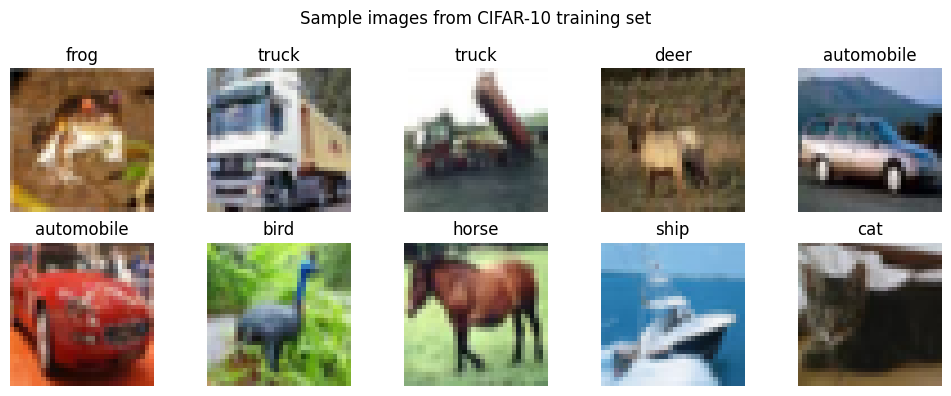

In [ ]:
# ============================================================
# Task A.2: Visualize a few sample images from the dataset
# ============================================================
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[i])
    plt.title(class_names[int(y_train_full[i])])
    plt.axis('off')
plt.suptitle("Sample images from CIFAR-10 training set")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Task A.3: Preprocess images - Resizing and Normalization
# ============================================================
# CIFAR-10 images are already a fixed 32x32 size, so no explicit resizing
# is required here. We normalize pixel values from the range [0, 255]
# to [0, 1] by dividing by 255.0. This helps the network train faster
# and more stably (smaller, well-scaled inputs).

x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the label arrays from shape (N, 1) to (N,) for convenience
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

print("Pixel value range after normalization -> min:", x_train_full.min(),
      "max:", x_train_full.max())


Pixel value range after normalization -> min: 0.0 max: 1.0


In [ ]:
# ============================================================
# Task A.4: Split the dataset into Training, Validation, and Testing sets
# ============================================================
# The original CIFAR-10 already provides a train/test split.
# Here we further split the training set into a training set and a
# validation set (used to monitor performance during training and
# tune hyperparameters), using a 90:10 split.

from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.1,          # 10% of training data reserved for validation
    random_state=42,
    stratify=y_train_full   # preserve class balance in both splits
)

print("Training set:  ", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Testing set:   ", x_test.shape, y_test.shape)


Training set:   (45000, 32, 32, 3) (45000,)
Validation set: (5000, 32, 32, 3) (5000,)
Testing set:    (10000, 32, 32, 3) (10000,)


---
## Task B: CNN MODEL IMPLEMENTATION

Build a CNN model consisting of:
- Convolution layers
- ReLU activation
- Max Pooling layers
- Fully Connected layers
- Softmax output layer

Compile the model using an appropriate optimizer and the cross-entropy loss function.


In [ ]:
# ============================================================
# Task B.1: Build the CNN architecture
# ============================================================
# Architecture:
#   Conv2D(32) -> ReLU -> MaxPooling
#   Conv2D(64) -> ReLU -> MaxPooling
#   Conv2D(64) -> ReLU
#   Flatten
#   Dense(64)  -> ReLU
#   Dropout    (regularization to reduce overfitting)
#   Dense(10)  -> Softmax (output layer, 10 classes)

model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # 1st Convolution block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # 2nd Convolution block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # 3rd Convolution block (feature extraction, no pooling after this one)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

    # Flatten feature maps into a 1D vector before the fully connected layers
    layers.Flatten(),

    # Fully connected (dense) layer
    layers.Dense(64, activation='relu'),

    # Dropout randomly disables 50% of neurons during training to prevent overfitting
    layers.Dropout(0.5),

    # Output layer: 10 units (one per class) with softmax activation
    # to output a probability distribution over the classes
    layers.Dense(10, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Task B.2: Compile the model
# ============================================================
# Optimizer : Adam (adaptive learning rate optimizer, generally converges
#             faster and more reliably than plain SGD).
# Loss      : Sparse Categorical Crossentropy - suitable since our labels
#             are integers (0-9) rather than one-hot encoded vectors.
# Metric    : Accuracy - fraction of correctly classified images.

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


---
## Task C: MODEL TRAINING AND EVALUATION

Train the CNN model and record training/validation accuracy & loss and testing accuracy.
Plot Accuracy vs Epoch and Loss vs Epoch.


In [ ]:
# ============================================================
# Task C.1: Train the CNN model
# ============================================================
# We train for 15 epochs with a batch size of 64, using the validation
# set created earlier to monitor generalization during training.

EPOCHS = 15
BATCH_SIZE = 64

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 131ms/step - accuracy: 0.3588 - loss: 1.7542 - val_accuracy: 0.5370 - val_loss: 1.3262
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.5065 - loss: 1.3724 - val_accuracy: 0.6192 - val_loss: 1.0991
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.5704 - loss: 1.2161 - val_accuracy: 0.6412 - val_loss: 1.0076
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.6092 - loss: 1.1112 - val_accuracy: 0.6590 - val_loss: 0.9534
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 128ms/step - accuracy: 0.6400 - loss: 1.0218 - val_accuracy: 0.6918 - val_loss: 0.8764
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 124ms/step - accuracy: 0.6658 - loss: 0.9557 - val_accuracy: 0.6958 - val_loss: 0.8756
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6843 - loss: 0.8989 - val_accuracy: 0.7060 - val_loss: 0.8505
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.6987 - los

In [ ]:
# ============================================================
# Task C.2: Record final Training / Validation accuracy and loss
# ============================================================
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy   : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")
print(f"Final Training Loss       : {final_train_loss:.4f}")
print(f"Final Validation Loss     : {final_val_loss:.4f}")


Final Training Accuracy   : 0.7720
Final Validation Accuracy : 0.7288
Final Training Loss       : 0.6260
Final Validation Loss     : 0.8440


In [ ]:
# ============================================================
# Task C.3: Evaluate the model on the held-out Test set
# ============================================================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Testing Loss     : {test_loss:.4f}")
print(f"Testing Accuracy : {test_acc:.4f}")


Testing Loss     : 0.8703
Testing Accuracy : 0.7234


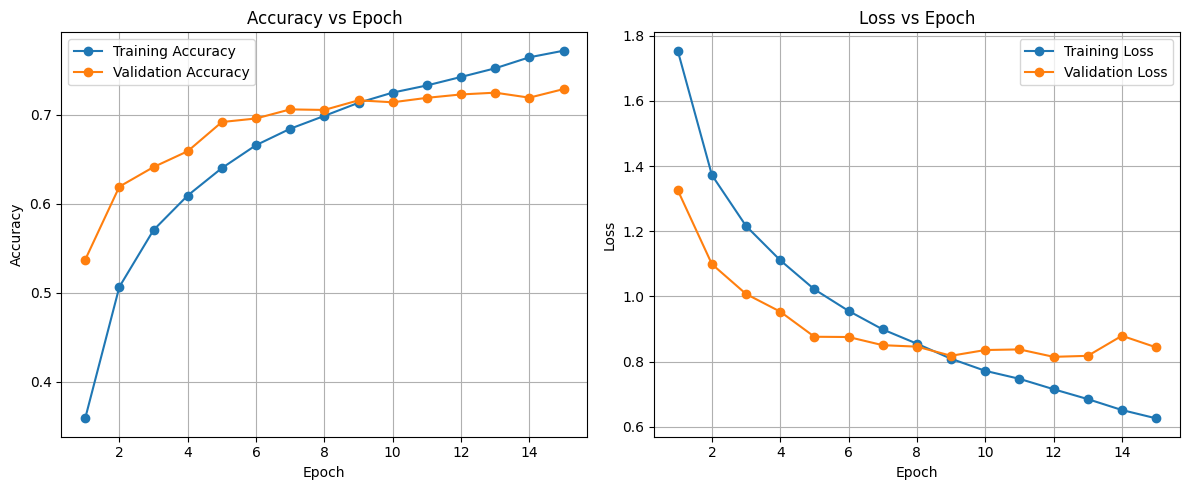

In [ ]:
# ============================================================
# Task C.4: Plot Accuracy vs Epoch and Loss vs Epoch
# ============================================================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# --- Accuracy plot ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Loss plot ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


---
## Task D: PERFORMANCE ANALYSIS

Analyze classification accuracy, confusion matrix, sample predictions, and misclassified images.


In [ ]:
# ============================================================
# Task D.1: Generate predictions on the test set
# ============================================================
y_pred_probs = model.predict(x_test)          # predicted probability for each class
y_pred = np.argmax(y_pred_probs, axis=1)      # predicted class label (highest probability)

print("Overall Classification Accuracy on Test Set: {:.2f}%".format(
    (y_pred == y_test).mean() * 100
))


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
Overall Classification Accuracy on Test Set: 72.34%


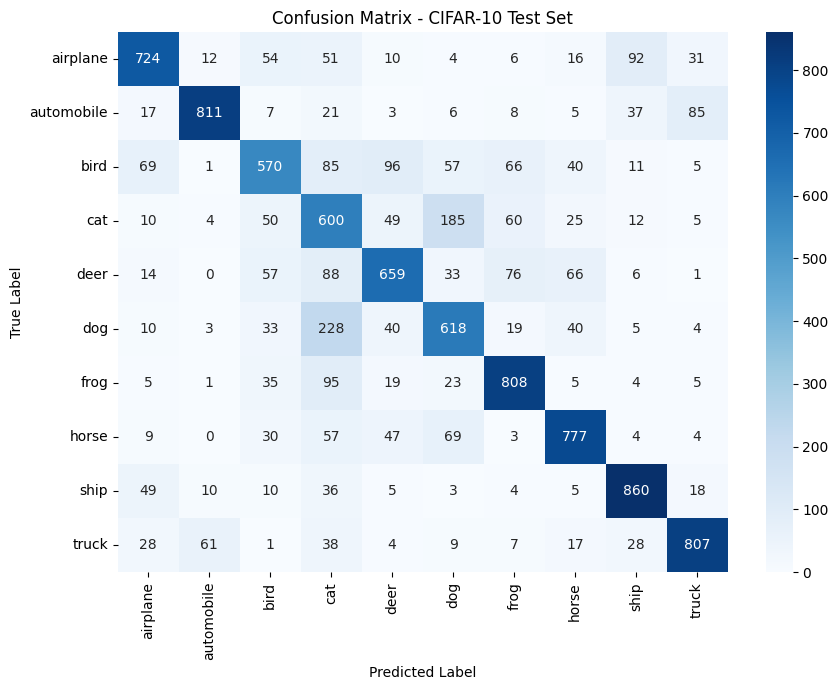

              precision    recall  f1-score   support

    airplane       0.77      0.72      0.75      1000
  automobile       0.90      0.81      0.85      1000
        bird       0.67      0.57      0.62      1000
         cat       0.46      0.60      0.52      1000
        deer       0.71      0.66      0.68      1000
         dog       0.61      0.62      0.62      1000
        frog       0.76      0.81      0.79      1000
       horse       0.78      0.78      0.78      1000
        ship       0.81      0.86      0.84      1000
       truck       0.84      0.81      0.82      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.73     10000
weighted avg       0.73      0.72      0.73     10000



In [ ]:
# ============================================================
# Task D.2: Confusion Matrix
# ============================================================
# The confusion matrix shows how many samples of each true class were
# predicted as each class, helping identify which classes are most
# frequently confused with one another.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CIFAR-10 Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Detailed per-class precision, recall, and F1-score
print(classification_report(y_test, y_pred, target_names=class_names))


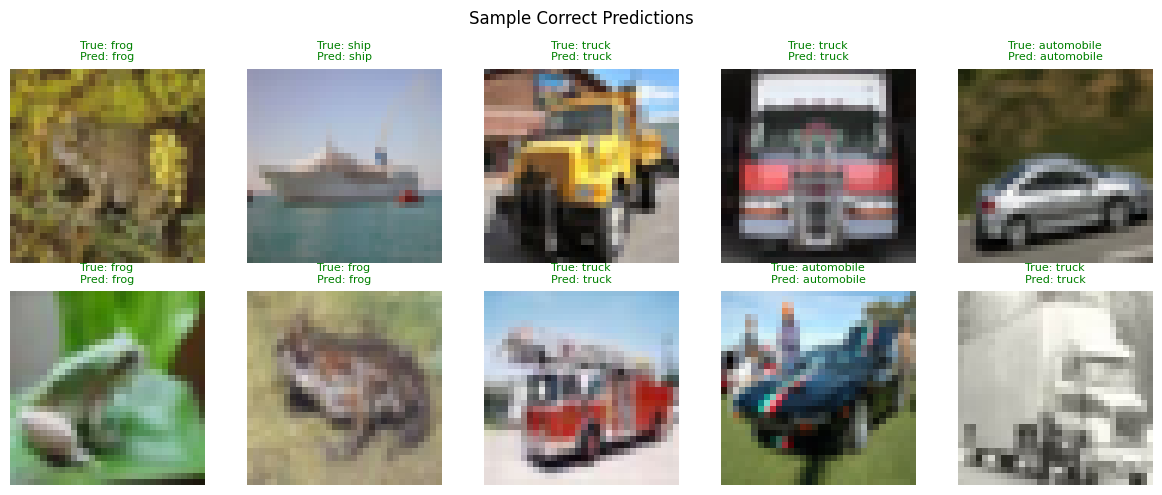

In [ ]:
# ============================================================
# Task D.3: Visualize sample correct predictions
# ============================================================
correct_idx = np.where(y_pred == y_test)[0]
sample_correct = np.random.choice(correct_idx, 10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(sample_correct):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}",
              fontsize=8, color='green')
    plt.axis('off')
plt.suptitle("Sample Correct Predictions")
plt.tight_layout()
plt.show()


Total misclassified images: 2766 out of 10000


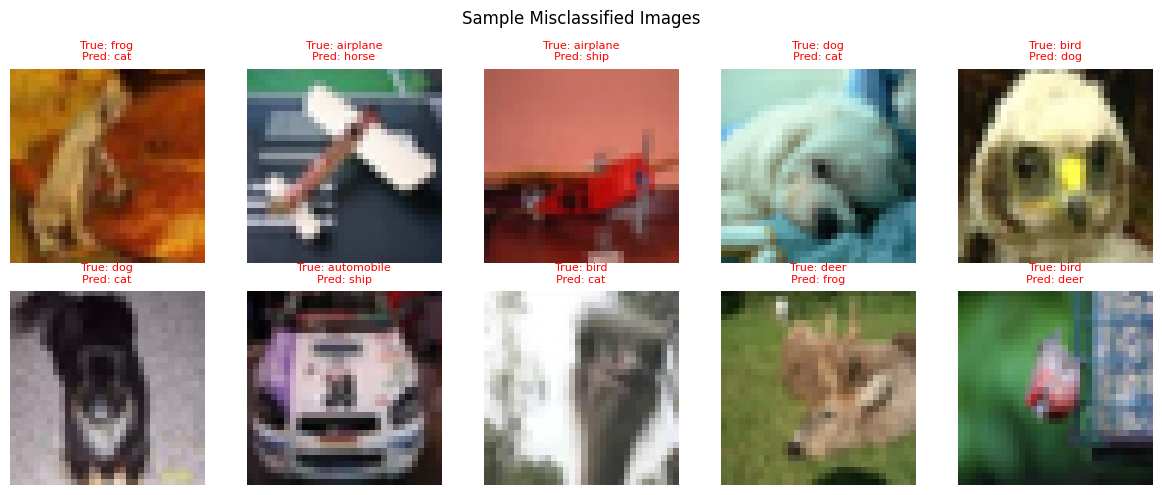

In [ ]:
# ============================================================
# Task D.4: Visualize misclassified images
# ============================================================
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified images: {len(misclassified_idx)} out of {len(y_test)}")

sample_wrong = np.random.choice(misclassified_idx, 10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(sample_wrong):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}",
              fontsize=8, color='red')
    plt.axis('off')
plt.suptitle("Sample Misclassified Images")
plt.tight_layout()
plt.show()
